In [1]:
import polars as pl
import pandas as pd
import numpy as np
import catboost
import os
from datetime import date, timedelta

In [2]:
test_start_date = date(2024, 8, 1)
val_start_date = date(2024, 7, 1)
val_end_date = date(2024, 7, 31)
train_end_date = date(2024, 6, 30)
data_path = './predict-user-fresh-order/'

# Read data

In [3]:
actions_history = pl.read_parquet(os.path.join(data_path, 'actions_history'))
search_history = pl.read_parquet(os.path.join(data_path, 'search_history'))
product_information = pl.read_csv(os.path.join(data_path, 'product_information.csv'))

In [4]:
product_information.head(100)

product_id,name,brand,type,category_id,category_name,price,discount_price
i64,str,str,str,i64,str,f64,f64
26176363,"""Развивающие тесты (3-4 года) (…","""Machaon""","""Печатная книга: Развитие детей""",780,"""Книги""",380.0,274.0
29898500,"""Mexx Туалетная вода Ice Touch …","""Mexx""","""Туалетная вода""",117,"""Мужская""",2645.0,1859.0
33967827,"""64 ГБ USB Флеш-накопитель USB …","""SmartBuy""","""USB-флеш-накопитель""",178,"""Флешки и CD-R""",1690.0,469.0
135938830,"""Чай листовой чёрный Ahmad Tea …","""Ahmad Tea""","""Чай листовой""",465,"""Чай листовой""",319.0,244.0
137920686,"""Seagate 4 ТБ Внешний жесткий д…","""Seagate""","""Внешний жесткий диск""",615,"""Внешние жесткие диски""",28590.0,9539.0
…,…,…,…,…,…,…,…
499019785,"""Набор для игры в покер ""Poker …","""Анзор Игра""","""Набор для покера""",5,"""Настольные игры для детей""",999.0,425.0
519410131,"""Органайзер для хранения / Орга…","""Baona""","""Органайзер для вещей""",37,"""Товары для дачи""",1490.0,838.0
524083710,"""Футляр для очков на магните му…","""O.Rissa""","""Футляр для очков""",56,"""Очки и аксессуары""",850.0,407.0


In [5]:
pl.read_csv(os.path.join(data_path, 'action_type_info.csv'))

action_type,action_type_id
str,i64
"""click""",1
"""favorite""",2
"""order""",3
"""search""",4
"""to_cart""",5
"""view""",6


In [6]:
val_start_date, val_end_date

(datetime.date(2024, 7, 1), datetime.date(2024, 7, 31))

In [7]:
val_target = (
    actions_history
    .filter(pl.col('timestamp').dt.date() >= val_start_date)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .select('user_id', (pl.col('action_type_id') == 3).alias('has_order'))
    .group_by('user_id')
    .agg(pl.max('has_order').cast(pl.Int32).alias('target'))
)

In [8]:
val_target.group_by('target').agg(pl.count('user_id'))

target,user_id
i32,u32
0,1227381
1,647575


In [9]:
val_target.group_by('target').agg(pl.count('user_id')).collect_schema()

Schema([('target', Int32), ('user_id', UInt32)])

# Simple pipeline

## Feats

In [10]:
train_end_date, train_end_date - timedelta(days=30 * 4)

(datetime.date(2024, 6, 30), datetime.date(2024, 3, 2))

In [11]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= train_end_date)
        .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type_id') == id_)
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [12]:
# search_aggs
id_ = 4
suf = 'search'
actions_aggs[id_] = (
    search_history
    .filter(pl.col('action_type_id') == id_)
    .filter(pl.col('timestamp').dt.date() <= train_end_date)
    .filter(pl.col('timestamp').dt.date() >= train_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(val_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(val_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [13]:
actions_aggs.keys()

dict_keys([1, 2, 3, 5, 4])

In [14]:
df = val_target
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [15]:
df

user_id,target,num_products_click,sum_discount_price_click,max_discount_price_click,days_since_last_click,days_since_first_click,num_products_favorite,sum_discount_price_favorite,max_discount_price_favorite,days_since_last_favorite,days_since_first_favorite,num_products_order,sum_discount_price_order,max_discount_price_order,days_since_last_order,days_since_first_order,num_products_to_cart,sum_discount_price_to_cart,max_discount_price_to_cart,days_since_last_to_cart,days_since_first_to_cart,num_search,days_since_last_search,days_since_first_search
i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,f32,f32,i32,i32,i32,i32,i32
1097407,1,130,45430.0,1399.0,5,106,2,234.0,117.0,80,80,26,4382.0,619.0,17,61,177,29397.0,639.0,5,108,245,5,108
10707531,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
8181485,1,1,539.0,539.0,120,120,null,null,null,null,null,null,null,null,null,null,1,539.0,539.0,120,120,null,null,null
2740363,0,2,804.0,445.0,75,75,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
6533950,1,85,34364.0,1900.0,3,106,14,7921.0,1235.0,14,101,7,1730.0,625.0,3,10,93,24163.0,964.0,2,111,104,1,111
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6724523,1,51,26522.0,6503.0,2,86,null,null,null,null,null,75,14436.0,1090.0,2,35,174,32648.0,1090.0,2,99,19,8,99
3151547,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
8548769,1,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,3,28,66


In [16]:
df_pd = df.to_pandas()

In [17]:
mask = df_pd.user_id % 10 <= 6

In [18]:
df_pd.columns

Index(['user_id', 'target', 'num_products_click', 'sum_discount_price_click',
       'max_discount_price_click', 'days_since_last_click',
       'days_since_first_click', 'num_products_favorite',
       'sum_discount_price_favorite', 'max_discount_price_favorite',
       'days_since_last_favorite', 'days_since_first_favorite',
       'num_products_order', 'sum_discount_price_order',
       'max_discount_price_order', 'days_since_last_order',
       'days_since_first_order', 'num_products_to_cart',
       'sum_discount_price_to_cart', 'max_discount_price_to_cart',
       'days_since_last_to_cart', 'days_since_first_to_cart', 'num_search',
       'days_since_last_search', 'days_since_first_search'],
      dtype='object')

In [19]:
cols = [
    'num_products_click', 
    'sum_discount_price_click', 'max_discount_price_click',
    'days_since_last_click', 'days_since_first_click',
    
    'num_products_favorite',
    'sum_discount_price_favorite', 'max_discount_price_favorite',
    'days_since_last_favorite', 'days_since_first_favorite',
    
    'num_products_order',
    'sum_discount_price_order', 'max_discount_price_order',
    'days_since_last_order', 'days_since_first_order',
    
    'num_products_to_cart',
    'sum_discount_price_to_cart', 'max_discount_price_to_cart',
    'days_since_last_to_cart', 'days_since_first_to_cart',
    
    'num_search',
    'days_since_last_search', 'days_since_first_search'
]

In [20]:
df_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1874956 entries, 0 to 1874955
Data columns (total 25 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   user_id                      int32  
 1   target                       int32  
 2   num_products_click           float64
 3   sum_discount_price_click     float32
 4   max_discount_price_click     float32
 5   days_since_last_click        float64
 6   days_since_first_click       float64
 7   num_products_favorite        float64
 8   sum_discount_price_favorite  float32
 9   max_discount_price_favorite  float32
 10  days_since_last_favorite     float64
 11  days_since_first_favorite    float64
 12  num_products_order           float64
 13  sum_discount_price_order     float32
 14  max_discount_price_order     float32
 15  days_since_last_order        float64
 16  days_since_first_order       float64
 17  num_products_to_cart         float64
 18  sum_discount_price_to_cart   float32
 19  

## Обработка данных

Сначала посмотрим на данные

In [21]:
from utils import plot_float_feature_histograms
from utils2 import AutoFeatureStandardizer

In [22]:
X = df_pd.loc[:, cols]
y = df_pd.loc[:].target

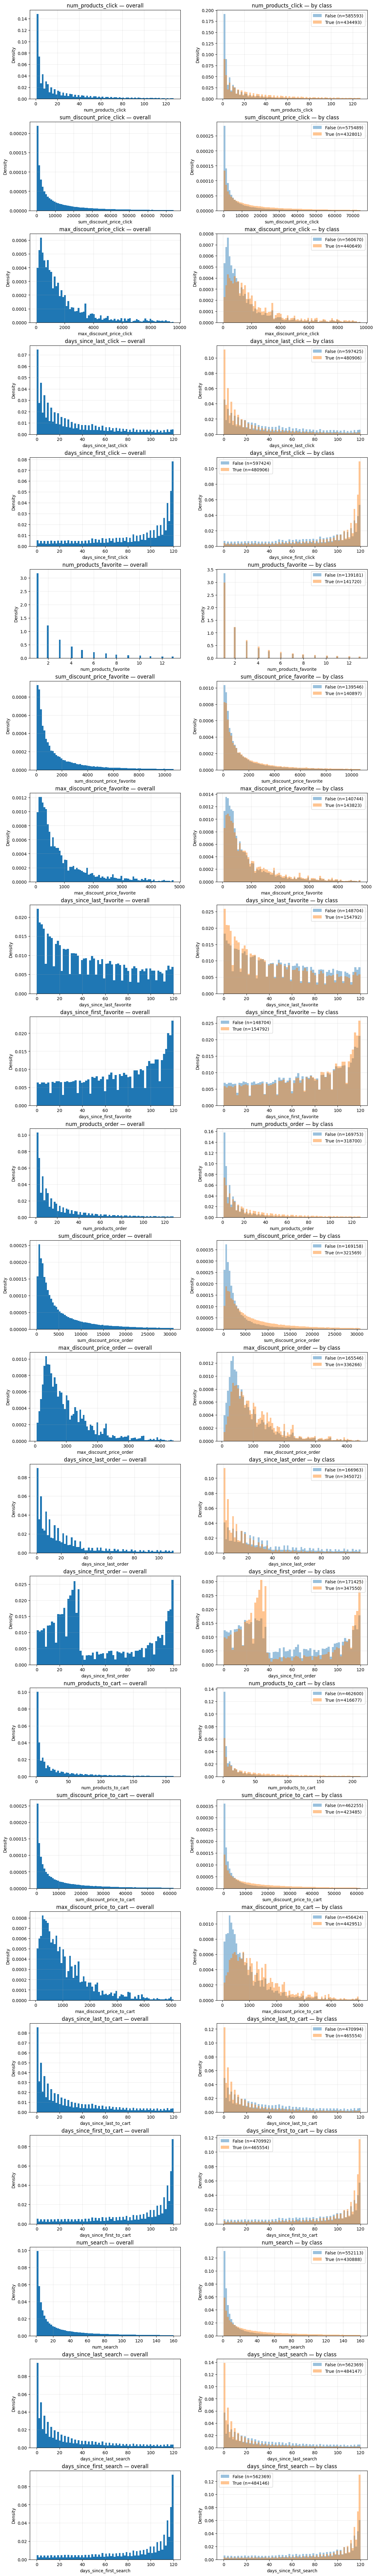

In [23]:
fig, axes = plot_float_feature_histograms(
    dataset=(X, y),
    class_0_label="False",
    class_1_label="True",
)

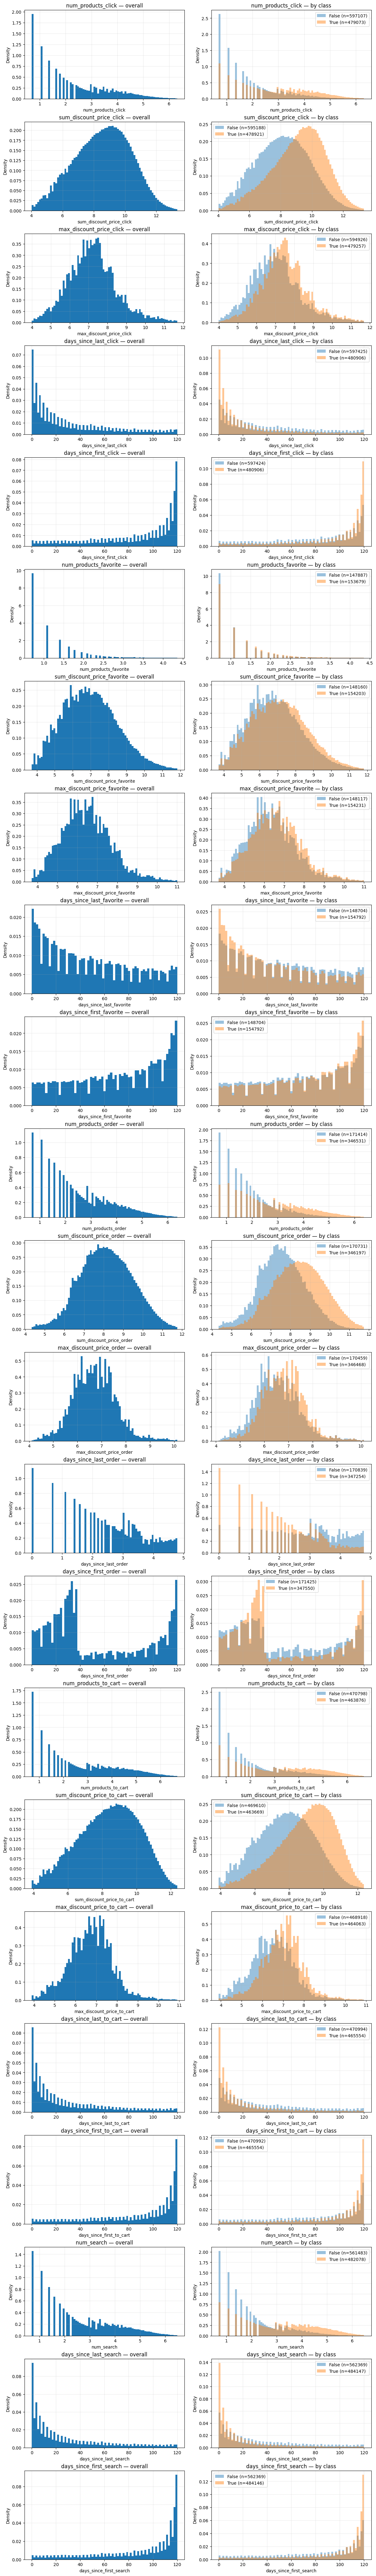

In [24]:
std = AutoFeatureStandardizer(add_indicators=False)

X_transformed = std.fit_transform(X)
fig, axes = plot_float_feature_histograms(
    dataset=(X_transformed, y),
    class_0_label="False",
    class_1_label="True",
)

In [54]:
X_train = X.loc[mask, cols]
y_train = y.loc[mask]
X_val = X.loc[~mask, cols]
y_val = y.loc[~mask]

In [26]:
params = {
    'iterations': 2000,
    'depth': 7, 
    'learning_rate': 0.05, 
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': 'GPU',
}

In [27]:
model = catboost.CatBoostClassifier(**params)
model.fit(X_train, y_train, early_stopping_rounds=50, use_best_model=True, eval_set=(X_val, y_val))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7462520	best: 0.7462520 (0)	total: 35.4ms	remaining: 1m 10s
1:	total: 43.8ms	remaining: 43.8s
2:	total: 52.1ms	remaining: 34.7s
3:	total: 60.5ms	remaining: 30.2s
4:	total: 69ms	remaining: 27.5s
5:	test: 0.7526379	best: 0.7526379 (5)	total: 77.5ms	remaining: 25.8s
6:	total: 85.3ms	remaining: 24.3s
7:	total: 93.1ms	remaining: 23.2s
8:	total: 101ms	remaining: 22.3s
9:	total: 109ms	remaining: 21.7s
10:	test: 0.7531833	best: 0.7531833 (10)	total: 117ms	remaining: 21.1s
11:	total: 126ms	remaining: 20.8s
12:	total: 134ms	remaining: 20.5s
13:	total: 142ms	remaining: 20.1s
14:	total: 150ms	remaining: 19.8s
15:	test: 0.7540358	best: 0.7540358 (15)	total: 158ms	remaining: 19.6s
16:	total: 166ms	remaining: 19.3s
17:	total: 174ms	remaining: 19.1s
18:	total: 182ms	remaining: 18.9s
19:	total: 190ms	remaining: 18.8s
20:	test: 0.7544352	best: 0.7544352 (20)	total: 198ms	remaining: 18.7s
21:	total: 206ms	remaining: 18.5s
22:	total: 214ms	remaining: 18.4s
23:	total: 222ms	remaining: 18.3s
24:	

## Версия 0.1
Ну в изначальном решении на первый бейзлайн какой-то кринж получился, так что начнём издевательство над моделью тут

In [28]:
from utils2 import BinaryClassifierInterpreter
import matplotlib.pyplot as plt

In [29]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train, y_train),
    val=(X_val, y_val),
    model=model,
    enable_early_stopping=True,
    use_best_model=True,
    early_stopping_rounds=100,
)

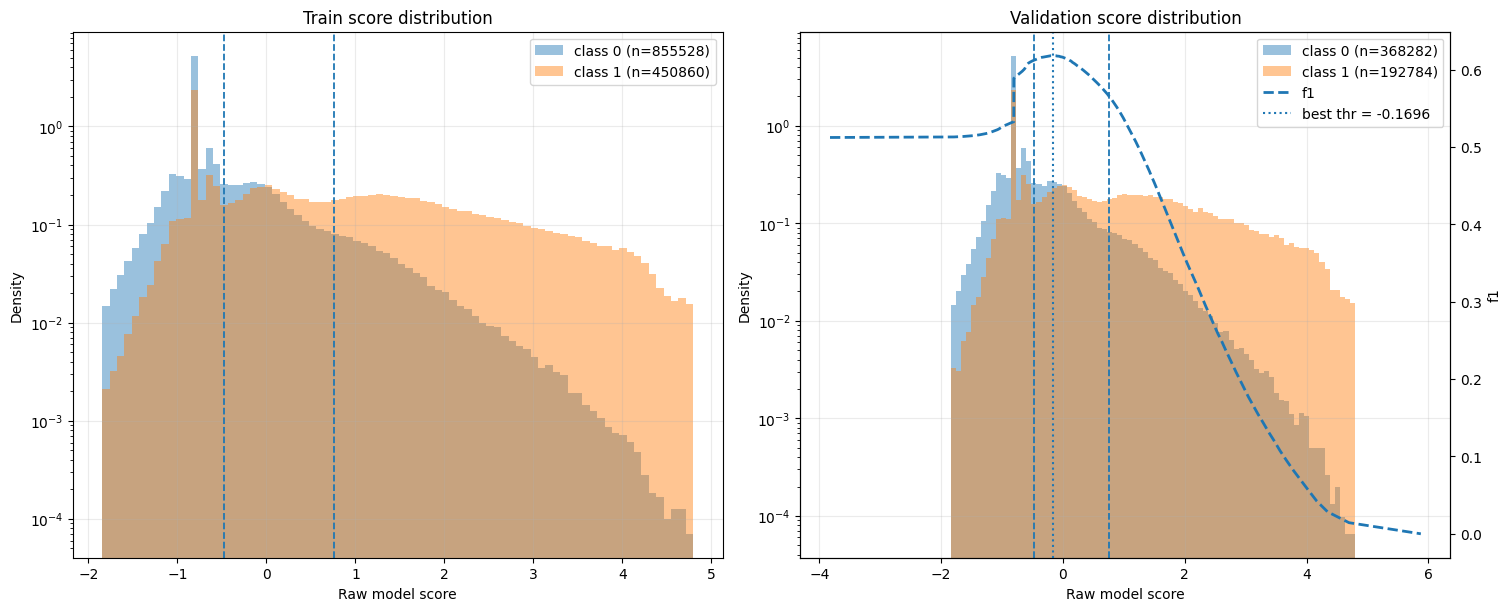

In [30]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

Ну уже видна лажа номер 1 - у нас есть уж очень частый скор и он точно не помогает нам различать два класса (в районе -0.7 если оценивать на глаз). Это надо будет поисследовать. Также можно увидеть, что две гистограммы в целом довольно сильно друг на друга наползают. 

ScoreFeatureContourPlotResult(fitted_model=<catboost.core.CatBoostClassifier object at 0x7ff97bb406e0>, fig=<Figure size 1600x700 with 6 Axes>, train_scores=array([ 1.54638065,  1.31447633,  1.13736301, ..., -0.80621186,
        0.12123998, -0.80621186], shape=(1311636,)), val_scores=array([-0.80621186, -0.80621186, -1.12986905, ..., -0.80621186,
        0.15344698, -0.90710042], shape=(563320,)), train_feature_values=array([9.3846302 , 9.22719765,        nan, ...,        nan, 8.70250988,
              nan], shape=(1311636,)), val_feature_values=array([       nan,        nan, 9.07920647, ...,        nan, 5.64544678,
       8.25192451], shape=(563320,)))

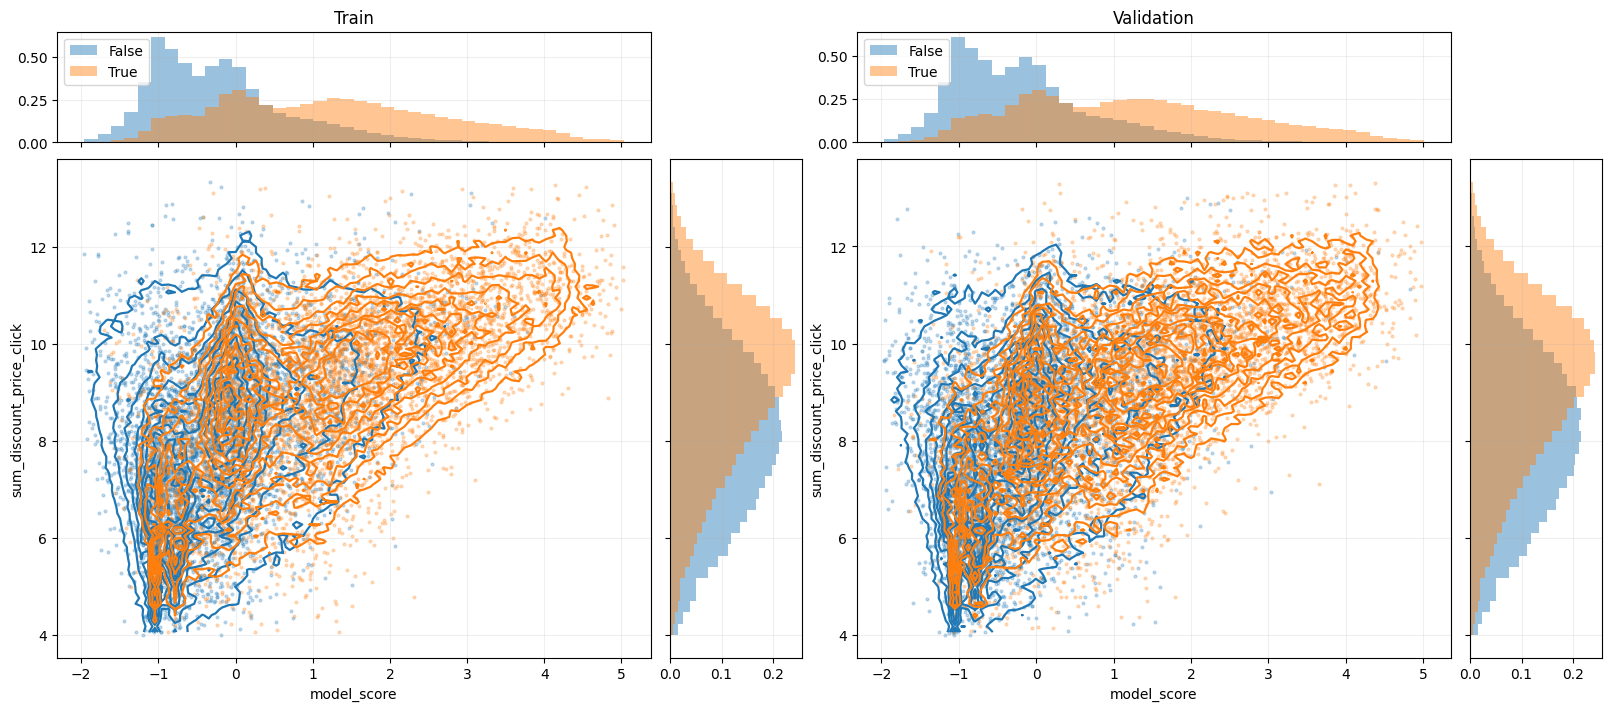

In [36]:
interpreter.plot_score_feature_contours(feature_name="sum_discount_price_click")

 99%|===================| 4973/5000 [01:22<00:00]        

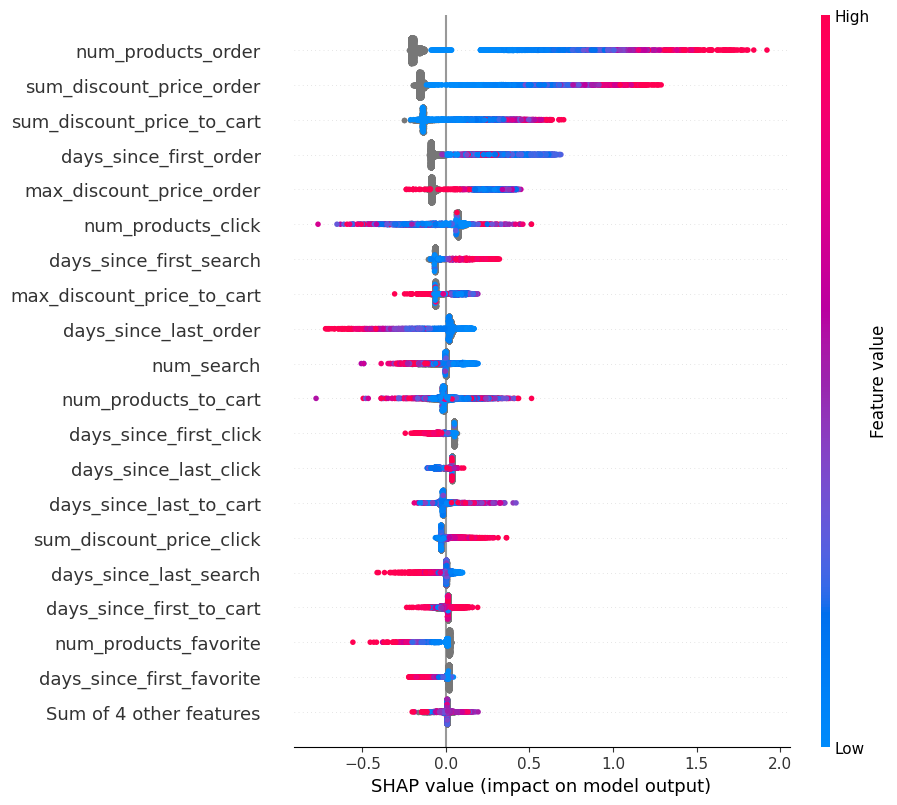

In [35]:
interpreter.plot_shap_beeswarm(max_display=20, sample_size=5000);

In [33]:
train_pool = catboost.Pool(
    X_train,
    label=y_train,
)
eval_pool = catboost.Pool(
    X_val,
    label=y_val,
)

In [34]:
train_pool.shape, eval_pool.shape

((1311636, 23), (563320, 23))

In [ ]:
model.fit(
    train_pool, 
    eval_set=eval_pool,
    use_best_model=True,
    verbose=10,
    early_stopping_rounds=50,
)

In [ ]:
name = 'baseline1'
model.save_model(f"{name}.bin")

In [ ]:
fi = model.get_feature_importance(eval_pool, prettified=True)
fi.head(50)

In [ ]:
test_users_submission = (
    pl.read_csv(os.path.join(data_path, 'test_users.csv'))
)

In [ ]:
val_end_date, val_end_date - timedelta(days=30 * 4)

In [ ]:
actions_aggs = {}
actions_id_to_suf = {
    1: "click",
    2: "favorite",
    3: "order",
    5: "to_cart",
}
for id_, suf in actions_id_to_suf.items():
    aggs = (
        actions_history
        .filter(pl.col('timestamp').dt.date() <= val_end_date)
        .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
        .filter(pl.col('action_type_id') == id_)
        .join(
            product_information
            .select('product_id', 'discount_price'),
            on='product_id',
        )
        .group_by('user_id')
        .agg(
            pl.count('product_id').cast(pl.Int32).alias(f'num_products_{suf}'),
            pl.sum('discount_price').cast(pl.Float32).alias(f'sum_discount_price_{suf}'),
            pl.max('discount_price').cast(pl.Float32).alias(f'max_discount_price_{suf}'),
            pl.max('timestamp').alias(f'last_{suf}_time'),
            pl.min('timestamp').alias(f'first_{suf}_time'),
        )
        .with_columns([
            (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_last_{suf}'),
            
            (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
            .dt.total_days()
            .cast(pl.Int32)
            .alias(f'days_since_first_{suf}'),
        ])
        .select(
            'user_id',
            f'num_products_{suf}',
            f'sum_discount_price_{suf}',
            f'max_discount_price_{suf}',
            f'days_since_last_{suf}',
            f'days_since_first_{suf}',
        )
    )
    actions_aggs[id_] = aggs

In [ ]:
# search_aggs
id_ = 4
suf = 'search'
actions_aggs[id_] = (
    search_history
    .filter(pl.col('action_type_id') == id_)
    .filter(pl.col('timestamp').dt.date() <= val_end_date)
    .filter(pl.col('timestamp').dt.date() >= val_end_date - timedelta(days=30 * 4))
    .group_by('user_id')
    .agg(
        pl.count('search_query').cast(pl.Int32).alias(f'num_{suf}'),
        pl.max('timestamp').alias(f'last_{suf}_time'),
        pl.min('timestamp').alias(f'first_{suf}_time'),
    )
    .with_columns([
        (pl.lit(test_start_date) - pl.col(f'last_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_last_{suf}'),

        (pl.lit(test_start_date) - pl.col(f'first_{suf}_time'))
        .dt.total_days()
        .cast(pl.Int32)
        .alias(f'days_since_first_{suf}'),
    ])
    .select(
        'user_id',
        f'num_{suf}',
        f'days_since_last_{suf}',
        f'days_since_first_{suf}',
    )
)

In [ ]:
df = test_users_submission
for _, actions_aggs_df in actions_aggs.items():
    df = (
        df
        .join(actions_aggs_df, on='user_id', how='left')
    )

In [ ]:
df_pd = df.to_pandas()

In [ ]:
df_pd.shape

In [ ]:
df_pd['predict'] = model.predict(df_pd[cols], prediction_type="Probability")[:, 1]

In [ ]:
df_pd[['user_id', 'predict']]

In [ ]:
df_pd[['user_id', 'predict']].to_csv('baseline1_submission.csv', index=False)